In [88]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/faridhasan007/fake-news/fake_and_real_news.csv
/kaggle/input/datasets/faridhasan007/fknews/fake_and_real_news.csv


In [89]:
# 1. Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

url = "/kaggle/input/datasets/faridhasan007/fake-news/fake_and_real_news.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
df.head()



Shape: (9900, 2)


,Text,label
0,Top Trump Surrogate BRUTALLY Stabs Him In The Back: ‘He’s Pathetic’ (VIDEO) It s looking as though Republican presidential candidate Donald Trump is losing support even from within his own ranks....,Fake
1,U.S. conservative leader optimistic of common ground on healthcare WASHINGTON (Reuters) - Republicans in the U.S. House of Representatives could achieve common ground on a deal to win support for ...,Real
2,"Trump proposes U.S. tax overhaul, stirs concerns on deficit WASHINGTON (Reuters) - President Donald Trump proposed on Wednesday the biggest U.S. tax overhaul in three decades, calling for tax cuts...",Real
3,"Court Forces Ohio To Allow Millions Of Illegally Purged Voters Back On The Rolls Donald Trump is semi-right: this election might be rigged. However, this election is rigged against the people, no...",Fake
4,"Democrats say Trump agrees to work on immigration bill, wall in dispute WASHINGTON (Reuters) - President Donald Trump and Democratic leaders in the U.S. Congress have agreed to work together on le...",Real


In [92]:
# 3. Inspect the Dataset
# Dataset Shape
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Dataset shape:", df.shape)

# First Few Rows
display(df.head())

# Data Types
print("Data types:")
print(df.dtypes)

Number of rows: 9900
Number of columns: 2
Dataset shape: (9900, 2)


,Text,label
0,Top Trump Surrogate BRUTALLY Stabs Him In The Back: ‘He’s Pathetic’ (VIDEO) It s looking as though Republican presidential candidate Donald Trump is losing support even from within his own ranks....,Fake
1,U.S. conservative leader optimistic of common ground on healthcare WASHINGTON (Reuters) - Republicans in the U.S. House of Representatives could achieve common ground on a deal to win support for ...,Real
2,"Trump proposes U.S. tax overhaul, stirs concerns on deficit WASHINGTON (Reuters) - President Donald Trump proposed on Wednesday the biggest U.S. tax overhaul in three decades, calling for tax cuts...",Real
3,"Court Forces Ohio To Allow Millions Of Illegally Purged Voters Back On The Rolls Donald Trump is semi-right: this election might be rigged. However, this election is rigged against the people, no...",Fake
4,"Democrats say Trump agrees to work on immigration bill, wall in dispute WASHINGTON (Reuters) - President Donald Trump and Democratic leaders in the U.S. Congress have agreed to work together on le...",Real


Data types:
Text     object
label    object
dtype: object


In [93]:
# Column Names
print("Column names:")
print(df.columns.tolist())


# Because the dataset is expected to contain only Text and label, verify this:

expected_columns = ["Text", "label"]

print("Expected columns:", expected_columns)
print("Actual columns:", df.columns.tolist())

# 4. Check Missing Values
print("Missing values:")
print(df.isnull().sum())

Column names:
['Text', 'label']
Expected columns: ['Text', 'label']
Actual columns: ['Text', 'label']
Missing values:
Text     0
label    0
dtype: int64


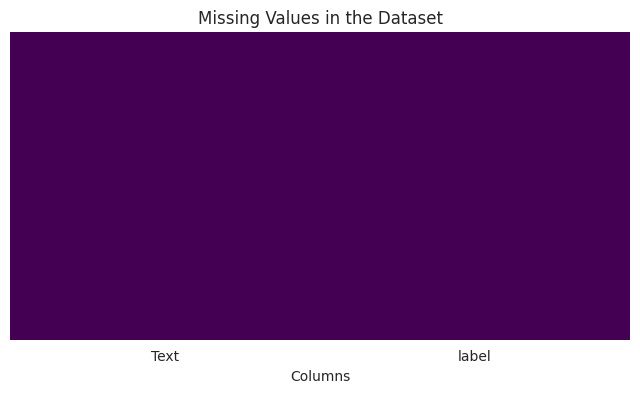

In [94]:
# Visualize missing values:

plt.figure(figsize=(8, 4))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap="viridis"
)

plt.title("Missing Values in the Dataset")
plt.xlabel("Columns")
plt.show()


In [95]:

# Check specifically for missing text and labels:

print("Missing Text values:", df["Text"].isnull().sum())
print("Missing label values:", df["label"].isnull().sum())

Missing Text values: 0
Missing label values: 0


In [97]:
# Find columns containing list values
for col in df.columns:
    if df[col].apply(lambda x: isinstance(x, list)).any():
        print(f"Column '{col}' contains list values")

In [98]:
# 5. Check Duplicate Articles

# Duplicate complete rows - ignore clean_tokens
duplicate_rows = df.drop(columns=['label']).duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)

# Duplicate articles based on Text
duplicate_articles = df.duplicated(subset=['Text']).sum()

print("Number of duplicate articles:", duplicate_articles)

# Display duplicated articles
duplicates = (
    df[df.duplicated(subset=['Text'], keep=False)]
    .sort_values('Text')
)

display(duplicates.head(10))

Number of duplicate rows: 35
Number of duplicate articles: 35


,Text,label
1427,"'Nuclear option' fallout? More extreme U.S. justices, experts say WASHINGTON (Reuters) - A Republican-backed Senate rule change expected on Thursday could make it more likely that presidents will ...",Real
4525,"'Nuclear option' fallout? More extreme U.S. justices, experts say WASHINGTON (Reuters) - A Republican-backed Senate rule change expected on Thursday could make it more likely that presidents will ...",Real
9244,Another U.S. appeals court refuses to revive Trump travel ban SAN FRANCISCO/WASHINGTON (Reuters) - President Donald Trump suffered another legal setback on Monday as a second federal appeals court...,Real
7627,Another U.S. appeals court refuses to revive Trump travel ban SAN FRANCISCO/WASHINGTON (Reuters) - President Donald Trump suffered another legal setback on Monday as a second federal appeals court...,Real
2010,Former Trump security aide was Russia blackmail risk: ex-U.S. official WASHINGTON (Reuters) - Former Acting U.S. Attorney General Sally Yates said on Monday she warned the White House in January t...,Real
3432,Former Trump security aide was Russia blackmail risk: ex-U.S. official WASHINGTON (Reuters) - Former Acting U.S. Attorney General Sally Yates said on Monday she warned the White House in January t...,Real
6829,Highlights: The Trump presidency on April 13 at 9:30 P.M. EDT/0130 GMT on Friday (Reuters) - Highlights for U.S. President Donald Trump’s administration on Thursday: The United States drops a mass...,Real
3861,Highlights: The Trump presidency on April 13 at 9:30 P.M. EDT/0130 GMT on Friday (Reuters) - Highlights for U.S. President Donald Trump’s administration on Thursday: The United States drops a mass...,Real
1576,Highlights: The Trump presidency on April 13 at 9:30 P.M. EDT/0130 GMT on Friday (Reuters) - Highlights for U.S. President Donald Trump’s administration on Thursday: The United States drops a mass...,Real
6684,Highlights: The Trump presidency on April 13 at 9:30 P.M. EDT/0130 GMT on Friday (Reuters) - Highlights for U.S. President Donald Trump’s administration on Thursday: The United States drops a mass...,Real


In [100]:
# 6. Check Label Values
print("Unique labels:")
print(df["label"].unique())


# Check the number of observations in each class:

label_counts = df["label"].value_counts()

print("Label counts:")
print(label_counts)


# Expected labels:

# Fake
# Real


# If necessary, remove accidental spaces:

df["label"] = df["label"].astype(str).str.strip()

print(df["label"].value_counts())

Unique labels:
['Fake' 'Real']
Label counts:
label
Fake    5000
Real    4900
Name: count, dtype: int64
label
Fake    5000
Real    4900
Name: count, dtype: int64


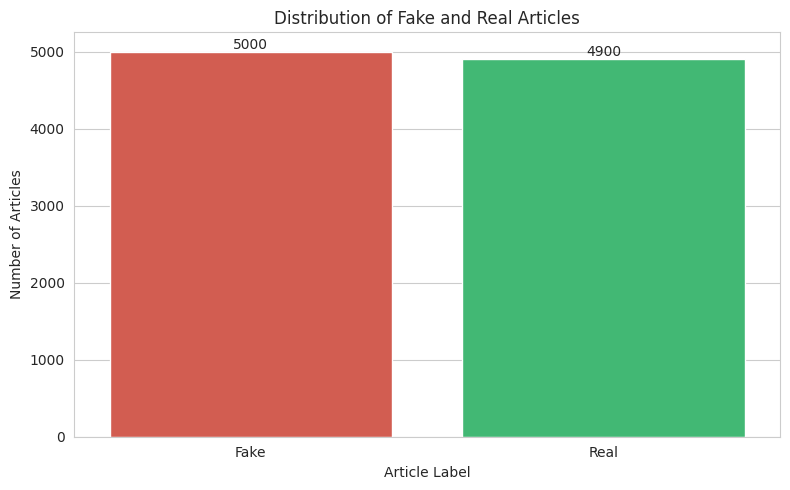

In [101]:
# 7. Label Distribution
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="label",
    hue="label",
    palette={
        "Fake": "#e74c3c",
        "Real": "#2ecc71"
    },
    legend=False
)

plt.title("Distribution of Fake and Real Articles")
plt.xlabel("Article Label")
plt.ylabel("Number of Articles")

# Add counts above bars
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

Label percentages:
label
Fake    50.51
Real    49.49
Name: proportion, dtype: float64


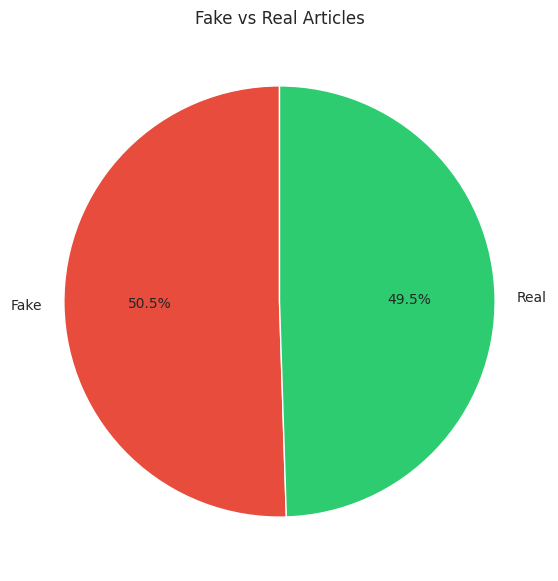

Largest class / smallest class ratio: 1.02
Conclusion: The dataset is approximately BALANCED.


In [102]:
# 8. Label Distribution as Percentages
label_percentages = (
    df["label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Label percentages:")
print(label_percentages)


# Visualize percentages:

plt.figure(figsize=(7, 7))

plt.pie(
    label_counts.values,
    labels=label_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#e74c3c", "#2ecc71"]
)

plt.title("Fake vs Real Articles")
plt.show()

# 9. Determine Whether the Dataset Is Balanced
largest_class = label_counts.max()
smallest_class = label_counts.min()

class_ratio = largest_class / smallest_class

print(f"Largest class / smallest class ratio: {class_ratio:.2f}")

if class_ratio <= 1.5:
    print("Conclusion: The dataset is approximately BALANCED.")
else:
    print("Conclusion: The dataset is IMBALANCED.")



The dataset contains 9,900 articles, with 5,000 (50.51%) labeled as Fake and 4,900 (49.49%) labeled as Real. The class distribution is approximately balanced, with only a 1.01 percentage-point difference between the two classes. Therefore, no significant class imbalance is present.

,Text,label,char_count,word_count,sentence_count
0,Top Trump Surrogate BRUTALLY Stabs Him In The Back: ‘He’s Pathetic’ (VIDEO) It s looking as though Republican presidential candidate Donald Trump is losing support even from within his own ranks....,Fake,1545,279,17
1,U.S. conservative leader optimistic of common ground on healthcare WASHINGTON (Reuters) - Republicans in the U.S. House of Representatives could achieve common ground on a deal to win support for ...,Real,758,116,7
2,"Trump proposes U.S. tax overhaul, stirs concerns on deficit WASHINGTON (Reuters) - President Donald Trump proposed on Wednesday the biggest U.S. tax overhaul in three decades, calling for tax cuts...",Real,6157,989,61
3,"Court Forces Ohio To Allow Millions Of Illegally Purged Voters Back On The Rolls Donald Trump is semi-right: this election might be rigged. However, this election is rigged against the people, no...",Fake,2269,364,17
4,"Democrats say Trump agrees to work on immigration bill, wall in dispute WASHINGTON (Reuters) - President Donald Trump and Democratic leaders in the U.S. Congress have agreed to work together on le...",Real,3748,594,29


char_count                                               word_count  \
           count         mean  median          std  min    max      count   
label                                                                       
Fake        5000  2691.300200  2498.0   914.560549  316  20356       5000   
Real        4900  2484.622449  2401.0  1751.989932  219  29849       4900   

                                               sentence_count             \
             mean median         std min   max          count       mean   
label                                                                      
Fake   449.408800  419.0  149.539806  46  3927           5000  24.850400   
Real   396.130816  382.5  282.562195  35  5181           4900  23.131224   

                                  
      median        std min  max  
label                             
Fake    23.0  11.591449   1  279  
Real    21.0  16.853684   1  337

Average article length by class:


,char_count,word_count,sentence_count
label,,,
Fake,2691.30,449.41,24.85
Real,2484.62,396.13,23.13


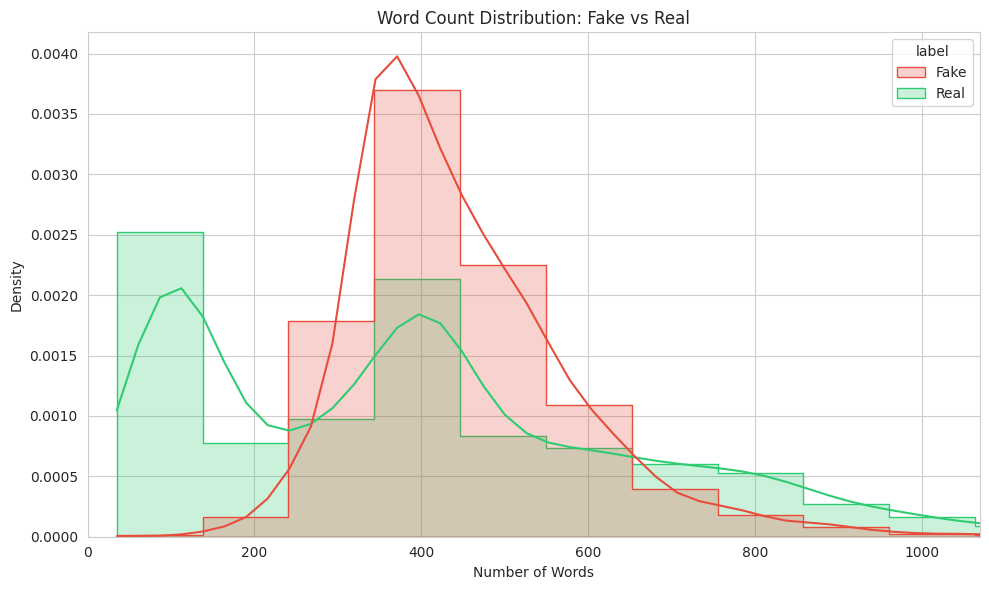

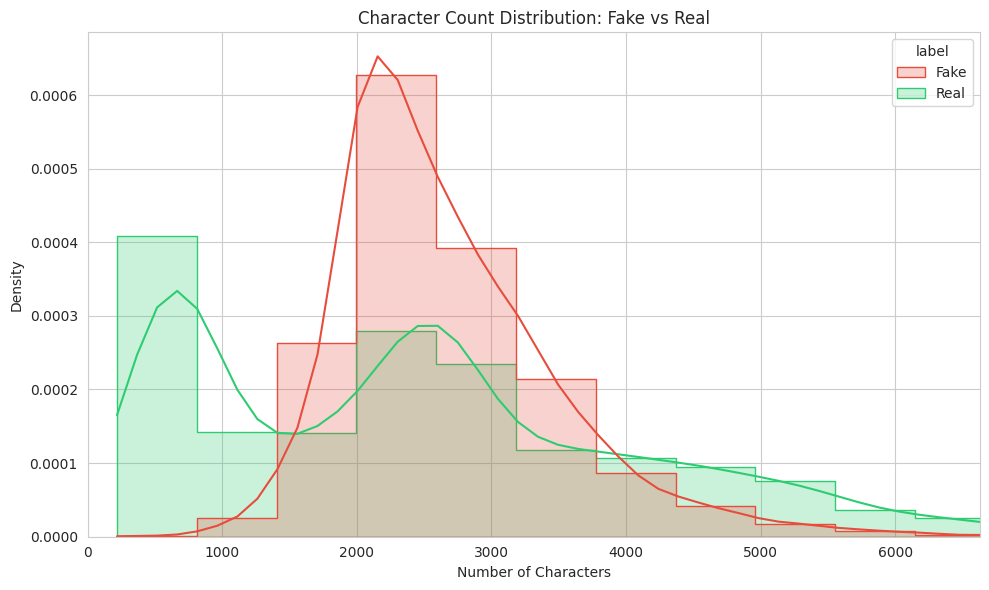

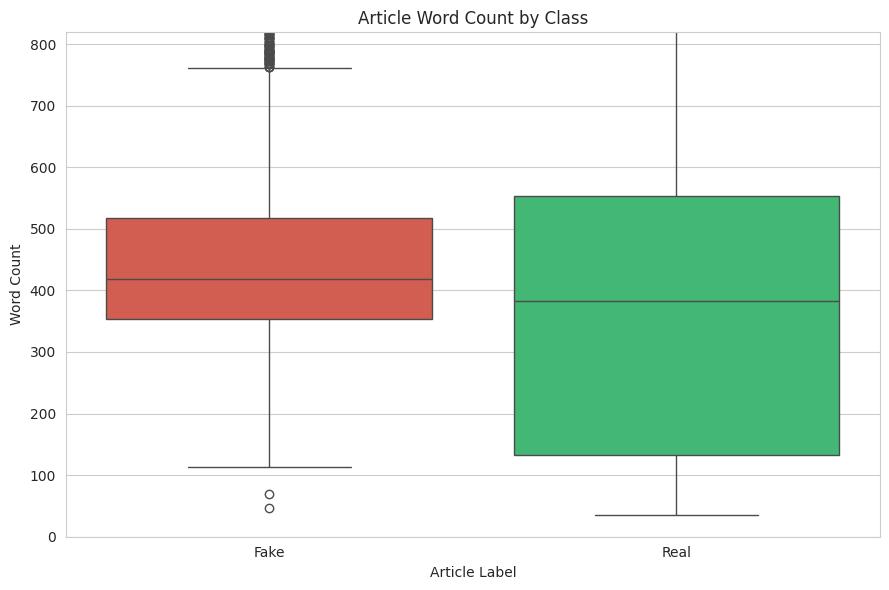

Median Fake article length: 419.0 words
Median Real article length: 382.5 words
Difference in median length: 36.5 words
Observation: Fake articles have a higher median word count.


In [103]:
# 10. Prepare Text for Length Analysis

# Before calculating text statistics, handle missing text values.

df["Text"] = df["Text"].fillna("").astype(str)


# Create article-length features.

# Character Count
df["char_count"] = df["Text"].str.len()

# Word Count
df["word_count"] = df["Text"].str.split().str.len()

# Sentence Count
df["sentence_count"] = df["Text"].str.count(r"[.!?]+")


# Inspect the new features:

display(
    df[
        ["Text", "label", "char_count", "word_count", "sentence_count"]
    ].head()
)

# 11. Article Length Statistics
length_stats = df.groupby("label")[
    ["char_count", "word_count", "sentence_count"]
].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

display(length_stats)


# A simpler summary:

simple_length_stats = df.groupby("label")[
    ["char_count", "word_count", "sentence_count"]
].mean().round(2)

print("Average article length by class:")
display(simple_length_stats)

# 12. Word Count Distribution
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="word_count",
    hue="label",
    bins=50,
    kde=True,
    element="step",
    stat="density",
    common_norm=False,
    palette={
        "Fake": "#e74c3c",
        "Real": "#2ecc71"
    }
)

plt.title("Word Count Distribution: Fake vs Real")
plt.xlabel("Number of Words")
plt.ylabel("Density")

# Ignore extreme outliers for easier visualization
plt.xlim(0, df["word_count"].quantile(0.99))

plt.tight_layout()
plt.show()

# 13. Character Count Distribution
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="char_count",
    hue="label",
    bins=50,
    kde=True,
    element="step",
    stat="density",
    common_norm=False,
    palette={
        "Fake": "#e74c3c",
        "Real": "#2ecc71"
    }
)

plt.title("Character Count Distribution: Fake vs Real")
plt.xlabel("Number of Characters")
plt.ylabel("Density")

plt.xlim(0, df["char_count"].quantile(0.99))

plt.tight_layout()
plt.show()

# 14. Article Length Box Plot
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="label",
    y="word_count",
    hue="label",
    palette={
        "Fake": "#e74c3c",
        "Real": "#2ecc71"
    },
    legend=False
)

plt.title("Article Word Count by Class")
plt.xlabel("Article Label")
plt.ylabel("Word Count")

# Limit extreme outliers
plt.ylim(0, df["word_count"].quantile(0.95))

plt.tight_layout()
plt.show()

# 15. Compare Median Article Length
fake_median = df.loc[
    df["label"] == "Fake", "word_count"
].median()

real_median = df.loc[
    df["label"] == "Real", "word_count"
].median()

print(f"Median Fake article length: {fake_median:.1f} words")
print(f"Median Real article length: {real_median:.1f} words")

difference = abs(fake_median - real_median)

print(f"Difference in median length: {difference:.1f} words")


# Automatic interpretation:

if fake_median > real_median:
    print("Observation: Fake articles have a higher median word count.")
elif real_median > fake_median:
    print("Observation: Real articles have a higher median word count.")
else:
    print("Observation: Fake and Real articles have the same median word count.")

In [104]:
# 16. Text Cleaning for Most Common Words

# This preprocessing is only for EDA. It should not be used to fit the final classifier outside the modeling pipeline.

stop_words = set(ENGLISH_STOP_WORDS)

def clean_text_for_eda(text):
    # Convert to lowercase
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Keep alphabetic characters
    text = re.sub(r"[^a-z\s]", " ", text)

    # Split into words
    words = text.split()

    # Remove stopwords and very short words
    words = [
        word
        for word in words
        if word not in stop_words and len(word) > 2
    ]

    return words


# Apply the cleaning function:

df["clean_tokens"] = df["Text"].apply(clean_text_for_eda)

display(
    df[["Text", "clean_tokens"]].head()
)


,Text,clean_tokens
0,Top Trump Surrogate BRUTALLY Stabs Him In The Back: ‘He’s Pathetic’ (VIDEO) It s looking as though Republican presidential candidate Donald Trump is losing support even from within his own ranks....,"[trump, surrogate, brutally, stabs, pathetic, video, looking, republican, presidential, candidate, donald, trump, losing, support, ranks, know, things, getting, bad, surrogates, start, turning, ex..."
1,U.S. conservative leader optimistic of common ground on healthcare WASHINGTON (Reuters) - Republicans in the U.S. House of Representatives could achieve common ground on a deal to win support for ...,"[conservative, leader, optimistic, common, ground, healthcare, washington, reuters, republicans, house, representatives, achieve, common, ground, deal, win, support, healthcare, legislation, thurs..."
2,"Trump proposes U.S. tax overhaul, stirs concerns on deficit WASHINGTON (Reuters) - President Donald Trump proposed on Wednesday the biggest U.S. tax overhaul in three decades, calling for tax cuts...","[trump, proposes, tax, overhaul, stirs, concerns, deficit, washington, reuters, president, donald, trump, proposed, wednesday, biggest, tax, overhaul, decades, calling, tax, cuts, americans, promp..."
3,"Court Forces Ohio To Allow Millions Of Illegally Purged Voters Back On The Rolls Donald Trump is semi-right: this election might be rigged. However, this election is rigged against the people, no...","[court, forces, ohio, allow, millions, illegally, purged, voters, rolls, donald, trump, semi, right, election, rigged, election, rigged, people, look, ohio, key, battleground, state, ending, elect..."
4,"Democrats say Trump agrees to work on immigration bill, wall in dispute WASHINGTON (Reuters) - President Donald Trump and Democratic leaders in the U.S. Congress have agreed to work together on le...","[democrats, say, trump, agrees, work, immigration, wall, dispute, washington, reuters, president, donald, trump, democratic, leaders, congress, agreed, work, legislation, protect, dreamers, illega..."


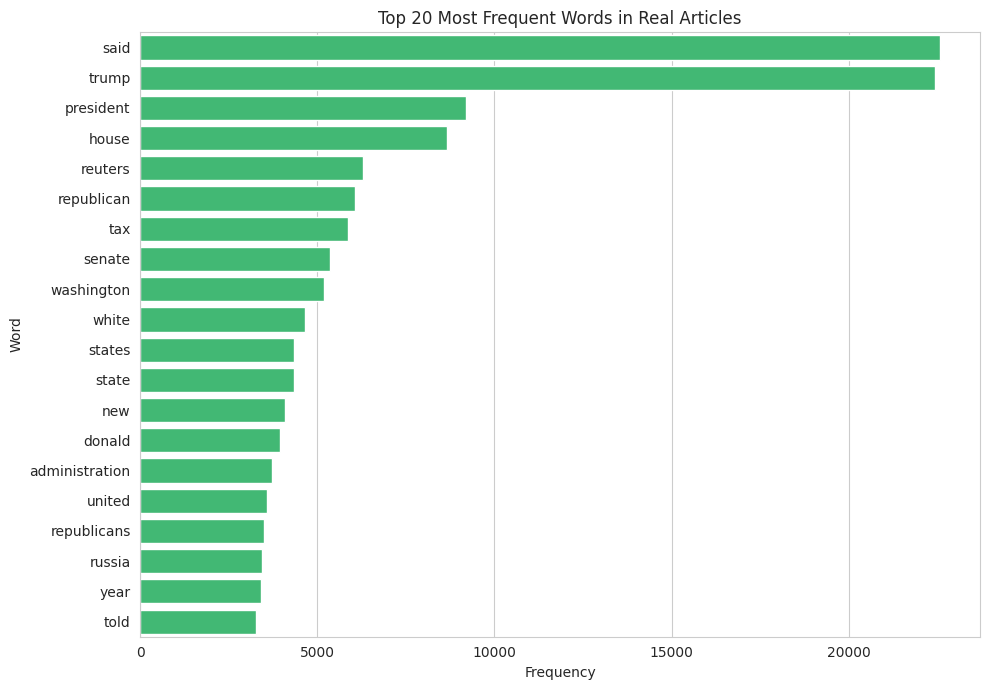

,Word,Frequency
0,said,22583
1,trump,22439
2,president,9190
3,house,8647
4,reuters,6300
5,republican,6057
6,tax,5860
7,senate,5358
8,washington,5192
9,white,4659


In [105]:
# 18. Top 20 Words in Real Articles
real_tokens = [
    word
    for tokens in df.loc[
        df["label"] == "Real", "clean_tokens"
    ]
    for word in tokens
]

real_word_counts = Counter(real_tokens)

top_real = real_word_counts.most_common(20)

real_words = [word for word, count in top_real]
real_counts = [count for word, count in top_real]


# Plot:

plt.figure(figsize=(10, 7))

sns.barplot(
    x=real_counts,
    y=real_words,
    color="#2ecc71"
)

plt.title("Top 20 Most Frequent Words in Real Articles")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.tight_layout()
plt.show()


# Display the results:

real_words_table = pd.DataFrame(
    top_real,
    columns=["Word", "Frequency"]
)

display(real_words_table)

In [106]:
# 19. Compare the Most Common Words
print("Top 10 Fake article words:")
print(", ".join(fake_words[:10]))

print("\nTop 10 Real article words:")
print(", ".join(real_words[:10]))

Top 10 Fake article words:
trump, donald, president, people, just, said, like, image, twitter, featured

Top 10 Real article words:
said, trump, president, house, reuters, republican, tax, senate, washington, white


In [111]:
# 20. Check Empty Articles

# Missing values and empty strings are different problems, so check both.

empty_articles = (
    df["Text"]
    .str.strip()
    .eq("")
    .sum()
)

print("Number of empty articles:", empty_articles)


# Check very short articles:

very_short_articles = (
    df["word_count"] < 3
).sum()

print("Articles containing fewer than 3 words:", very_short_articles)

Number of empty articles: 0
Articles containing fewer than 3 words: 0


In [112]:
# 21. Final Data Quality Summary
print("=" * 50)
print("DATA QUALITY SUMMARY")
print("=" * 50)

print(f"Total articles: {len(df):,}")
print(f"Total columns: {df.shape[1]:,}")

print("\nMissing values:")
print(df[["Text", "label"]].isnull().sum())

# print("\nDuplicate complete rows:")
# print(df.duplicated().sum())

print("\nDuplicate articles:")
print(df.duplicated(subset=["Text"]).sum())

print("\nEmpty articles:")
print(empty_articles)

print("\nArticles with fewer than 3 words:")
print(very_short_articles)

print("\nClass distribution:")
print(df["label"].value_counts())

print("\nArticle length:")
print(df.groupby("label")["word_count"].describe())

DATA QUALITY SUMMARY
Total articles: 9,900
Total columns: 6

Missing values:
Text     0
label    0
dtype: int64

Duplicate articles:
35

Empty articles:
0

Articles with fewer than 3 words:
0

Class distribution:
label
Fake    5000
Real    4900
Name: count, dtype: int64

Article length:
        count        mean         std   min    25%    50%    75%     max
label                                                                   
Fake   5000.0  449.408800  149.539806  46.0  354.0  419.0  517.0  3927.0
Real   4900.0  396.130816  282.562195  35.0  133.0  382.5  554.0  5181.0


In [113]:
# 22. Key Findings

# Run the following cell to produce a concise data-driven summary.

fake_count = (df["label"] == "Fake").sum()
real_count = (df["label"] == "Real").sum()

total = len(df)

fake_pct = fake_count / total * 100
real_pct = real_count / total * 100

ratio = max(fake_count, real_count) / min(fake_count, real_count)

fake_mean_words = df.loc[
    df["label"] == "Fake", "word_count"
].mean()

real_mean_words = df.loc[
    df["label"] == "Real", "word_count"
].mean()

fake_median_words = df.loc[
    df["label"] == "Fake", "word_count"
].median()

real_median_words = df.loc[
    df["label"] == "Real", "word_count"
].median()

print("KEY FINDINGS")
print("=" * 60)

# Target balance
print("\n1. Target balance")
print(f"   Fake: {fake_count:,} ({fake_pct:.2f}%)")
print(f"   Real: {real_count:,} ({real_pct:.2f}%)")

if ratio <= 1.5:
    print("   The target is approximately balanced.")
else:
    print("   The target is imbalanced.")

# Article length
print("\n2. Article length")
print(f"   Fake mean:   {fake_mean_words:.1f} words")
print(f"   Real mean:   {real_mean_words:.1f} words")
print(f"   Fake median: {fake_median_words:.1f} words")
print(f"   Real median: {real_median_words:.1f} words")

if abs(fake_median_words - real_median_words) > 0.10 * max(
    fake_median_words, real_median_words
):
    print("   There appears to be a meaningful difference in article length.")
else:
    print("   Article lengths are broadly similar.")

# Common words
print("\n3. Common words")

print("   Fake articles:")
print("   " + ", ".join(fake_words[:10]))

print("\n   Real articles:")
print("   " + ", ".join(real_words[:10]))

# Data quality
print("\n4. Data quality")

missing_text = df["Text"].isnull().sum()
missing_labels = df["label"].isnull().sum()
duplicates = df.duplicated(subset=["Text"]).sum()

print(f"   Missing Text values: {missing_text}")
print(f"   Missing label values: {missing_labels}")
print(f"   Duplicate articles: {duplicates}")
print(f"   Empty articles: {empty_articles}")
print(f"   Very short articles: {very_short_articles}")

KEY FINDINGS

1. Target balance
   Fake: 5,000 (50.51%)
   Real: 4,900 (49.49%)
   The target is approximately balanced.

2. Article length
   Fake mean:   449.4 words
   Real mean:   396.1 words
   Fake median: 419.0 words
   Real median: 382.5 words
   Article lengths are broadly similar.

3. Common words
   Fake articles:
   trump, donald, president, people, just, said, like, image, twitter, featured

   Real articles:
   said, trump, president, house, reuters, republican, tax, senate, washington, white

4. Data quality
   Missing Text values: 0
   Missing label values: 0
   Duplicate articles: 35
   Empty articles: 0
   Very short articles: 0


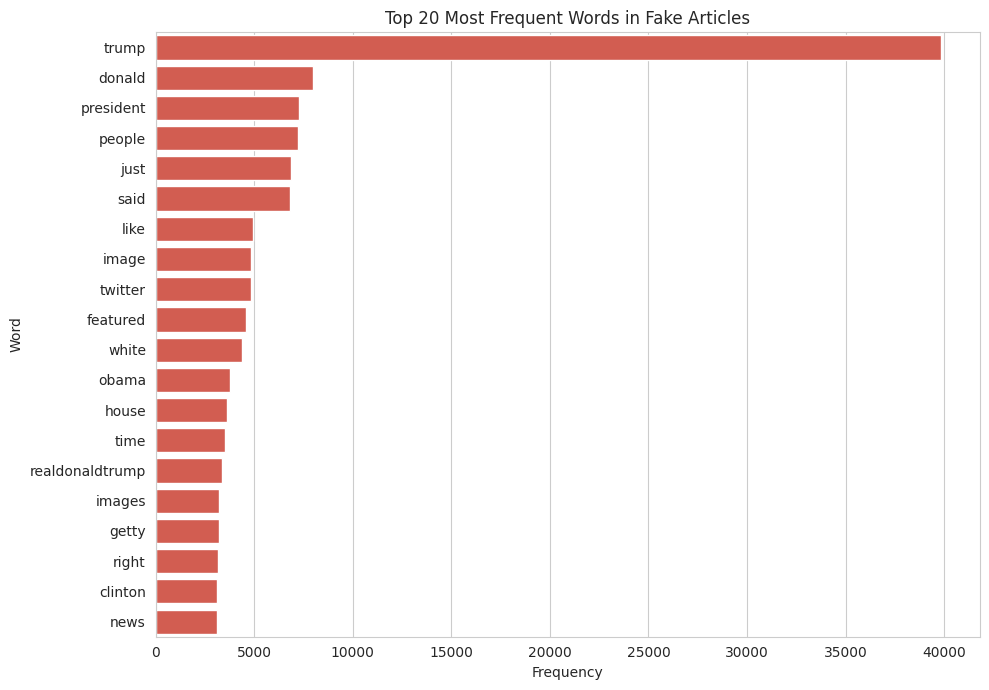

,Word,Frequency
0,trump,39830
1,donald,7991
2,president,7290
3,people,7202
4,just,6870
5,said,6826
6,like,4928
7,image,4860
8,twitter,4837
9,featured,4580


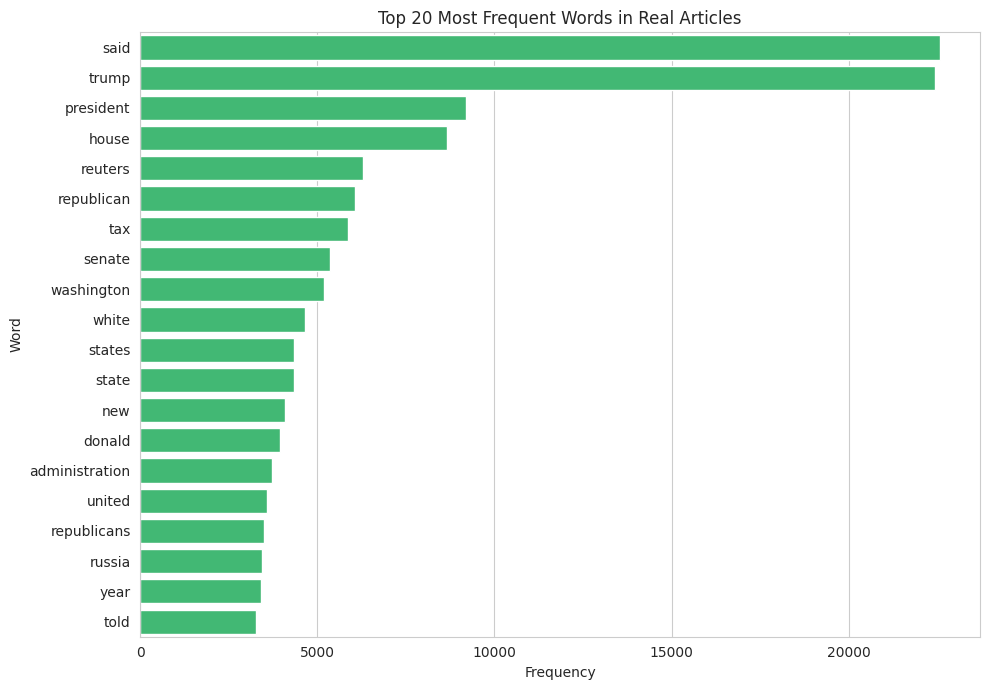

,Word,Frequency
0,said,22583
1,trump,22439
2,president,9190
3,house,8647
4,reuters,6300
5,republican,6057
6,tax,5860
7,senate,5358
8,washington,5192
9,white,4659


Top 10 Fake article words:
trump, donald, president, people, just, said, like, image, twitter, featured

Top 10 Real article words:
said, trump, president, house, reuters, republican, tax, senate, washington, white
Number of empty articles: 0
Articles containing fewer than 3 words: 0
DATA QUALITY SUMMARY
Total articles: 9,900
Total columns: 6

Missing values:
Text     0
label    0
dtype: int64

Duplicate articles:
35

Empty articles:
0

Articles with fewer than 3 words:
0

Class distribution:
label
Fake    5000
Real    4900
Name: count, dtype: int64

Article length:
        count        mean         std   min    25%    50%    75%     max
label                                                                   
Fake   5000.0  449.408800  149.539806  46.0  354.0  419.0  517.0  3927.0
Real   4900.0  396.130816  282.562195  35.0  133.0  382.5  554.0  5181.0
KEY FINDINGS

1. Target balance
   Fake: 5,000 (50.51%)
   Real: 4,900 (49.49%)
   The target is approximately balanced.

2. Article le

In [114]:
# 17. Top 20 Words in Fake Articles
fake_tokens = [
    word
    for tokens in df.loc[
        df["label"] == "Fake", "clean_tokens"
    ]
    for word in tokens
]

fake_word_counts = Counter(fake_tokens)

top_fake = fake_word_counts.most_common(20)

fake_words = [word for word, count in top_fake]
fake_counts = [count for word, count in top_fake]


# Plot:

plt.figure(figsize=(10, 7))

sns.barplot(
    x=fake_counts,
    y=fake_words,
    color="#e74c3c"
)

plt.title("Top 20 Most Frequent Words in Fake Articles")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.tight_layout()
plt.show()


# Display the results:

fake_words_table = pd.DataFrame(
    top_fake,
    columns=["Word", "Frequency"]
)

display(fake_words_table)

# 18. Top 20 Words in Real Articles
real_tokens = [
    word
    for tokens in df.loc[
        df["label"] == "Real", "clean_tokens"
    ]
    for word in tokens
]

real_word_counts = Counter(real_tokens)

top_real = real_word_counts.most_common(20)

real_words = [word for word, count in top_real]
real_counts = [count for word, count in top_real]


# Plot:

plt.figure(figsize=(10, 7))

sns.barplot(
    x=real_counts,
    y=real_words,
    color="#2ecc71"
)

plt.title("Top 20 Most Frequent Words in Real Articles")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.tight_layout()
plt.show()


# Display the results:

real_words_table = pd.DataFrame(
    top_real,
    columns=["Word", "Frequency"]
)

display(real_words_table)

# 19. Compare the Most Common Words
print("Top 10 Fake article words:")
print(", ".join(fake_words[:10]))

print("\nTop 10 Real article words:")
print(", ".join(real_words[:10]))

# 20. Check Empty Articles

# Missing values and empty strings are different problems, so check both.

empty_articles = (
    df["Text"]
    .str.strip()
    .eq("")
    .sum()
)

print("Number of empty articles:", empty_articles)


# Check very short articles:

very_short_articles = (
    df["word_count"] < 3
).sum()

print("Articles containing fewer than 3 words:", very_short_articles)

# 21. Final Data Quality Summary
print("=" * 50)
print("DATA QUALITY SUMMARY")
print("=" * 50)

print(f"Total articles: {len(df):,}")
print(f"Total columns: {df.shape[1]:,}")

print("\nMissing values:")
print(df[["Text", "label"]].isnull().sum())

# print("\nDuplicate complete rows:")
# print(df.duplicated().sum())

print("\nDuplicate articles:")
print(df.duplicated(subset=["Text"]).sum())

print("\nEmpty articles:")
print(empty_articles)

print("\nArticles with fewer than 3 words:")
print(very_short_articles)

print("\nClass distribution:")
print(df["label"].value_counts())

print("\nArticle length:")
print(df.groupby("label")["word_count"].describe())

# 22. Key Findings

# Run the following cell to produce a concise data-driven summary.

fake_count = (df["label"] == "Fake").sum()
real_count = (df["label"] == "Real").sum()

total = len(df)

fake_pct = fake_count / total * 100
real_pct = real_count / total * 100

ratio = max(fake_count, real_count) / min(fake_count, real_count)

fake_mean_words = df.loc[
    df["label"] == "Fake", "word_count"
].mean()

real_mean_words = df.loc[
    df["label"] == "Real", "word_count"
].mean()

fake_median_words = df.loc[
    df["label"] == "Fake", "word_count"
].median()

real_median_words = df.loc[
    df["label"] == "Real", "word_count"
].median()

print("KEY FINDINGS")
print("=" * 60)

# Target balance
print("\n1. Target balance")
print(f"   Fake: {fake_count:,} ({fake_pct:.2f}%)")
print(f"   Real: {real_count:,} ({real_pct:.2f}%)")

if ratio <= 1.5:
    print("   The target is approximately balanced.")
else:
    print("   The target is imbalanced.")

# Article length
print("\n2. Article length")
print(f"   Fake mean:   {fake_mean_words:.1f} words")
print(f"   Real mean:   {real_mean_words:.1f} words")
print(f"   Fake median: {fake_median_words:.1f} words")
print(f"   Real median: {real_median_words:.1f} words")

if abs(fake_median_words - real_median_words) > 0.10 * max(
    fake_median_words, real_median_words
):
    print("   There appears to be a meaningful difference in article length.")
else:
    print("   Article lengths are broadly similar.")

# Common words
print("\n3. Common words")

print("   Fake articles:")
print("   " + ", ".join(fake_words[:10]))

print("\n   Real articles:")
print("   " + ", ".join(real_words[:10]))

# Data quality
print("\n4. Data quality")

missing_text = df["Text"].isnull().sum()
missing_labels = df["label"].isnull().sum()
duplicates = df.duplicated(subset=["Text"]).sum()

print(f"   Missing Text values: {missing_text}")
print(f"   Missing label values: {missing_labels}")
print(f"   Duplicate articles: {duplicates}")
print(f"   Empty articles: {empty_articles}")
print(f"   Very short articles: {very_short_articles}")

EDA Conclusion
The following should be included in the notebook after running the analysis. Replace the bracketed values with the actual results from your output.

Key Findings
Target balance:
The dataset contains [Fake count] Fake articles and [Real count] Real articles. The class ratio is approximately [ratio]. Therefore, the target is [balanced/imbalanced].

Article length:
The median Fake article contains approximately [Fake median] words, while the median Real article contains approximately [Real median] words. The distributions should be compared using the histogram and box plot. A noticeable separation would suggest that article length may contain some useful information, although text content is expected to be much more important for the NLP classifier.

Frequently occurring words:
After lowercasing, removing URLs, punctuation, stopwords, and very short words, the most frequent words can be seen in the two bar charts. Fake articles are dominated by [top Fake words], while Real articles are dominated by [top Real words]. Words occurring in both classes represent general news vocabulary, whereas words that are much more common in one class may provide useful classification signals.

Data quality:
The dataset should be checked for missing text/labels, duplicate articles, empty articles, and extremely short articles. Duplicate articles are particularly important because identical or near-identical articles appearing in both training and test sets can lead to overly optimistic model performance.

Preparation before training:
Missing text or labels should be handled before modeling, and duplicate articles should be removed where appropriate. The raw text should then be split into training and test sets before model fitting. TfidfVectorizer or CountVectorizer must be placed inside the scikit-learn Pipeline so that the vocabulary and IDF statistics are learned only from the training data. The held-out test set should be used only once for the final evaluation.